In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')

In [21]:
import pandas as pd
from sqlalchemy import create_engine

# Read CSV
df = pd.read_csv("Telco-Customer-Churn.csv")

# Create SQLite database
engine = create_engine("sqlite:///churn.db")

# Store dataframe into SQL table
df.to_sql(
    "customers",
    engine,
    if_exists="replace",
    index=False
)

7043

# Load data

In [2]:
df = pd.read_csv(r"C:\Users\Asus\OneDrive\Desktop\Zaalima Project\project 1\Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

# Data Structure

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Missing Values

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Target Variable Analysis

## Q1. What % of Customer Churn?

In [7]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df['Churn'].value_counts(normalize = True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [22]:
query = """
SELECT
    Churn,
    COUNT(*) AS Customer_Count,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM customers),
        2
    ) AS Percentage
FROM customers
GROUP BY Churn;
"""

pd.read_sql(query, engine)

,Churn,Customer_Count,Percentage
0,No,5174,73.46
1,Yes,1869,26.54


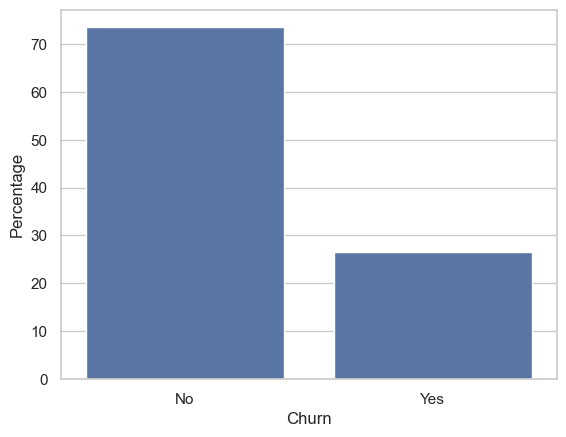

In [23]:
result = pd.read_sql(query, engine)

sns.barplot(
    x='Churn',
    y='Percentage',
    data=result
)

plt.show()

#### INSIGHT: Dataset is imbalanced

# Numerical Features vs Churn

## Q2. Does tenure affect churn?

In [25]:
query = """
SELECT
    Churn,
    AVG(tenure) AS Avg_Tenure,
    MIN(tenure) AS Min_Tenure,
    MAX(tenure) AS Max_Tenure
FROM customers
GROUP BY Churn;
"""

pd.read_sql(query, engine)

,Churn,Avg_Tenure,Min_Tenure,Max_Tenure
0,No,37.569965,0,72
1,Yes,17.979133,1,72


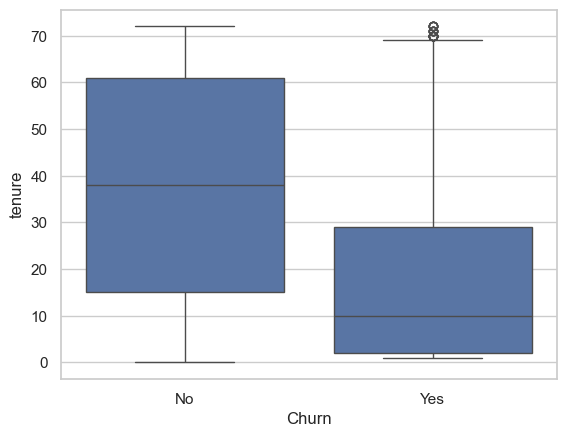

In [27]:
df_sql = pd.read_sql(
    "SELECT tenure, Churn FROM customers",
    engine
)

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df_sql
)

plt.show()

#### INSIGHT: Low tenure -> High churn 
####          New users are risky 

## Q3. Do high-paying customers churn more?

In [28]:
query = """
SELECT
    Churn,
    AVG(MonthlyCharges) AS Avg_Monthly_Charge
FROM customers
GROUP BY Churn;
"""

pd.read_sql(query, engine)

,Churn,Avg_Monthly_Charge
0,No,61.265124
1,Yes,74.441332


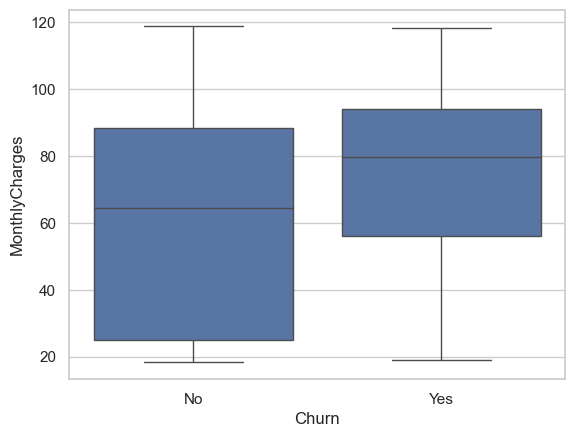

In [29]:
df_sql = pd.read_sql(
    "SELECT MonthlyCharges, Churn FROM customers",
    engine
)

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df_sql
)

plt.show()

#### INSIGHT: Higher charges -> higher churn 

## Q4. Total revenue vs churn

In [30]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.to_sql(
    "customers",
    engine,
    if_exists="replace",
    index=False
)

7043

In [31]:
query = """
SELECT
    Churn,
    AVG(TotalCharges) AS Avg_Revenue
FROM customers
GROUP BY Churn;
"""

pd.read_sql(query, engine)

,Churn,Avg_Revenue
0,No,2555.344141
1,Yes,1531.796094


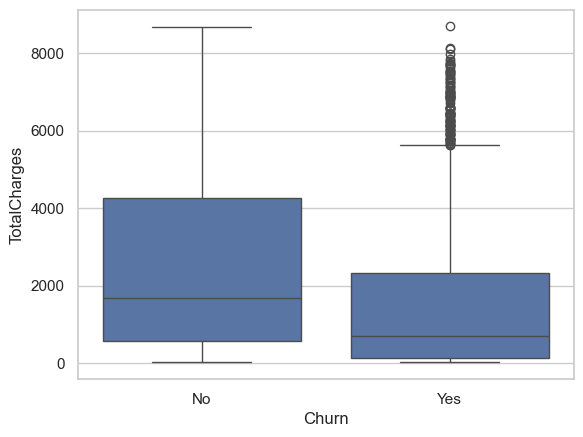

In [32]:
df_sql = pd.read_sql(
    "SELECT TotalCharges, Churn FROM customers",
    engine
)

sns.boxplot(
    x='Churn',
    y='TotalCharges',
    data=df_sql
)

plt.show()

# Categorical Features vs Churn

## Q5. Does contract type affect churn?

In [33]:
query = """
SELECT
    Contract,
    Churn,
    COUNT(*) AS Total_Customers
FROM customers
GROUP BY Contract, Churn;
"""

pd.read_sql(query, engine)

,Contract,Churn,Total_Customers
0,Month-to-month,No,2220
1,Month-to-month,Yes,1655
2,One year,No,1307
3,One year,Yes,166
4,Two year,No,1647
5,Two year,Yes,48


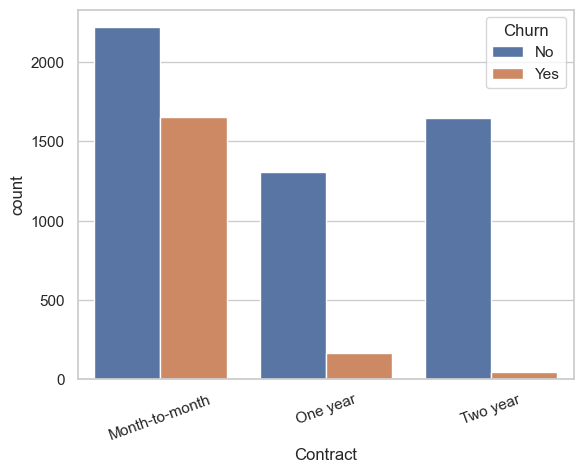

In [34]:
df_sql = pd.read_sql(
    """
    SELECT Contract, Churn
    FROM customers
    """,
    engine
)

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df_sql
)

plt.xticks(rotation=20)
plt.show()

#### INSIGHT: Month-to-month -> highest churn and Long-term -> stable

## Q6. Does internet services type affect churn?

In [35]:
query = """
SELECT
    InternetService,
    Churn,
    COUNT(*) AS Count
FROM customers
GROUP BY InternetService, Churn;
"""

pd.read_sql(query, engine)

,InternetService,Churn,Count
0,DSL,No,1962
1,DSL,Yes,459
2,Fiber optic,No,1799
3,Fiber optic,Yes,1297
4,No,No,1413
5,No,Yes,113


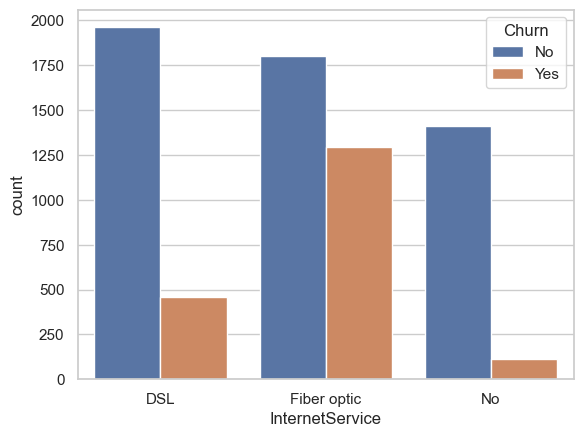

In [36]:
df_sql = pd.read_sql(
    """
    SELECT InternetService, Churn
    FROM customers
    """,
    engine
)

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df_sql
)

plt.show()

## Q7. Payment method impact ?

In [37]:
query = """
SELECT
    PaymentMethod,
    Churn,
    COUNT(*) AS Count
FROM customers
GROUP BY PaymentMethod, Churn;
"""

pd.read_sql(query, engine)

,PaymentMethod,Churn,Count
0,Bank transfer (automatic),No,1286
1,Bank transfer (automatic),Yes,258
2,Credit card (automatic),No,1290
3,Credit card (automatic),Yes,232
4,Electronic check,No,1294
5,Electronic check,Yes,1071
6,Mailed check,No,1304
7,Mailed check,Yes,308


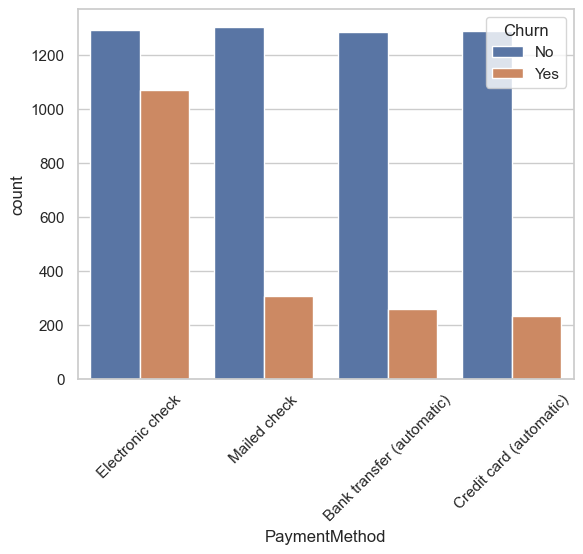

In [38]:
df_sql = pd.read_sql(
    """
    SELECT PaymentMethod, Churn
    FROM customers
    """,
    engine
)

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df_sql
)

plt.xticks(rotation=45)
plt.show()

#### INSIGHT: Electronic check users churn more

## Q8. Gender imapct ?

In [39]:
query = """
SELECT
    gender,
    Churn,
    COUNT(*) AS Count
FROM customers
GROUP BY gender, Churn;
"""

pd.read_sql(query, engine)

,gender,Churn,Count
0,Female,No,2549
1,Female,Yes,939
2,Male,No,2625
3,Male,Yes,930


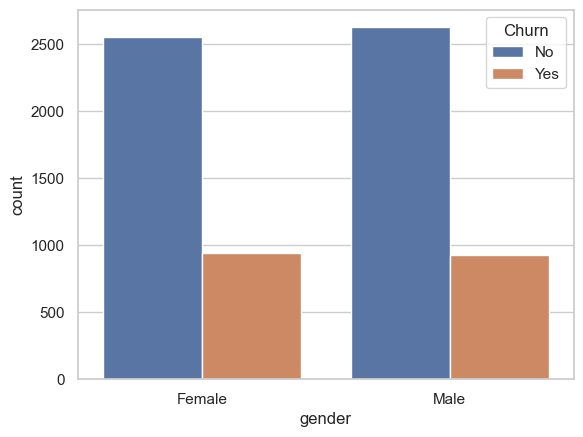

In [40]:
df_sql = pd.read_sql(
    """
    SELECT gender, Churn
    FROM customers
    """,
    engine
)

sns.countplot(
    x='gender',
    hue='Churn',
    data=df_sql
)

plt.show()

#### INSIGHT: Usually no strong difference

# Correlation Analysis

## Q9. Which features are most correlated?

In [41]:
query = """
SELECT
    tenure,
    MonthlyCharges,
    TotalCharges,
    Churn
FROM customers
"""

corr_df = pd.read_sql(query, engine)

corr_df["Churn"] = corr_df["Churn"].map(
    {"Yes":1,"No":0}
)

corr_df.corr(numeric_only=True)

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.247900,0.825880,-0.352229
MonthlyCharges,0.247900,1.000000,0.651065,0.193356
TotalCharges,0.825880,0.651065,1.000000,-0.199484
Churn,-0.352229,0.193356,-0.199484,1.000000


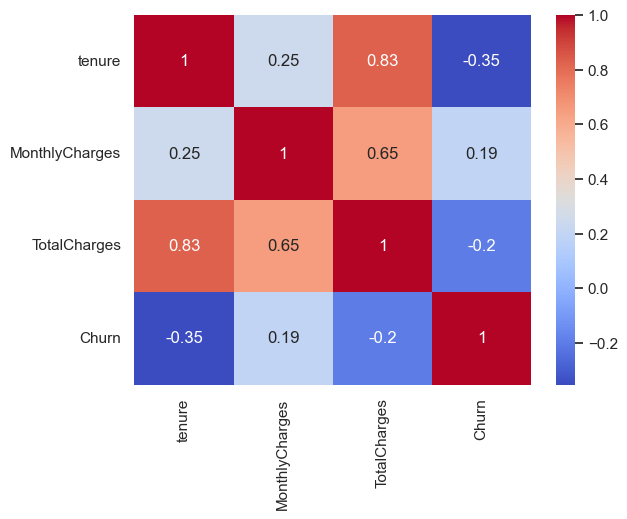

In [42]:
import seaborn as sns

sns.heatmap(
    corr_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.show()

#### INSIGHT: Tenure -> negative correlation and MonthlyCharges -> positive

# Pair Plot

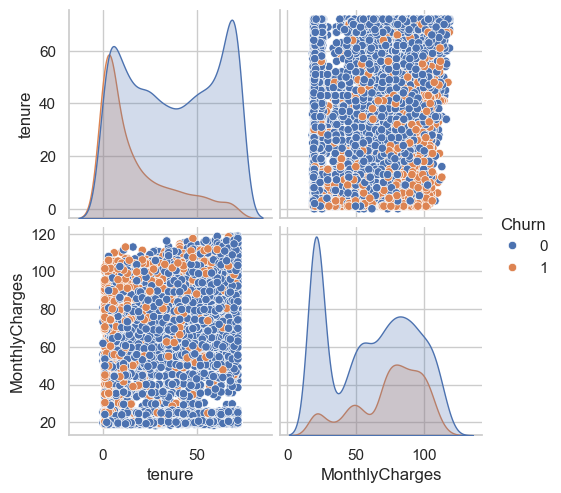

In [18]:
sns.pairplot(df[['tenure','MonthlyCharges','TotalCharges','Churn']], hue='Churn')
plt.show()

# Class Imbalance check 

In [19]:
df['Churn'].value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

# Feature Distribution

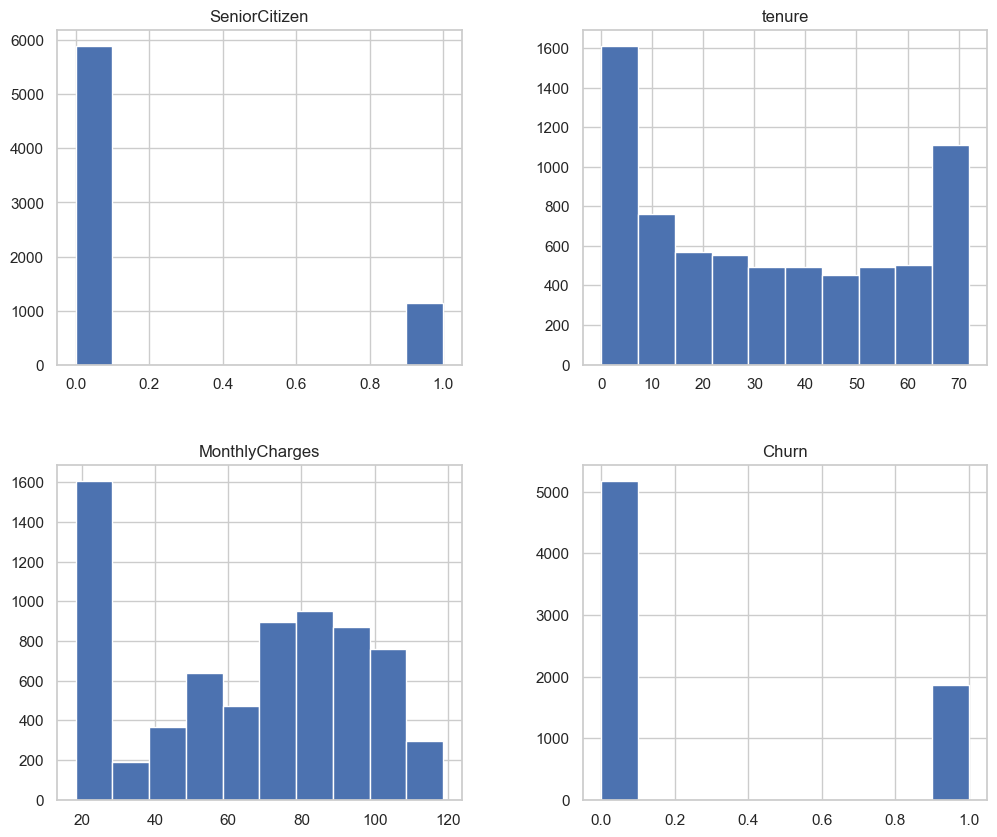

In [20]:
df.hist(figsize=(12,10))
plt.show()

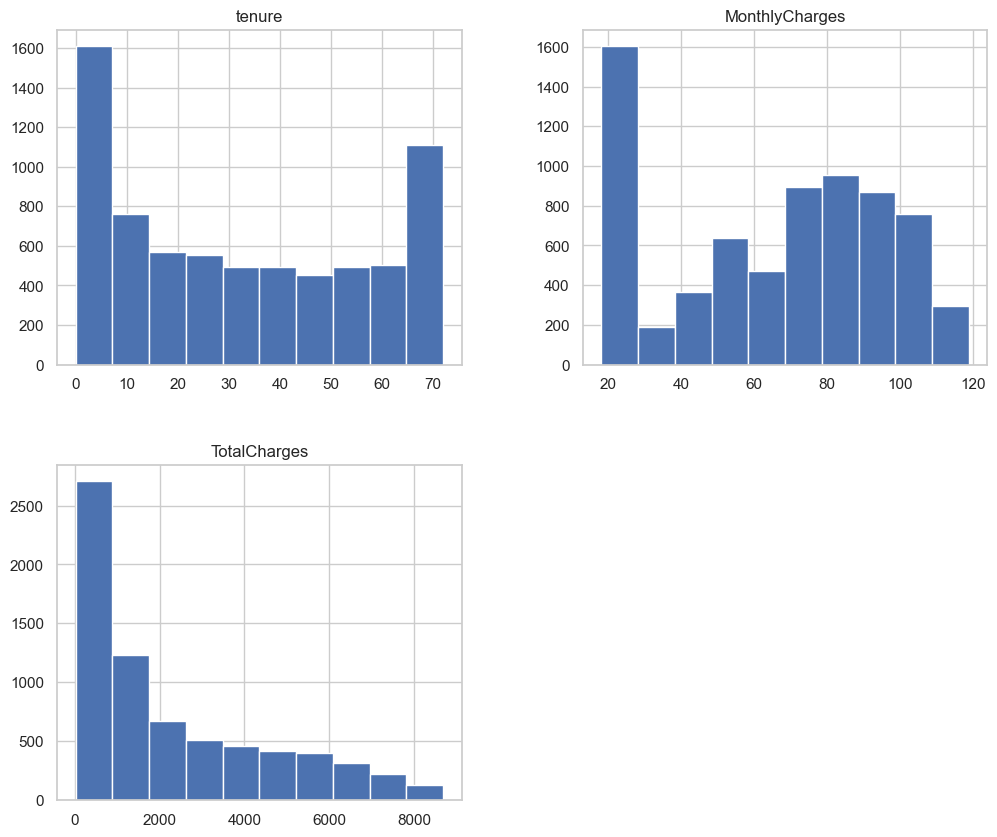

In [43]:
query = """
SELECT
    tenure,
    MonthlyCharges,
    TotalCharges
FROM customers
"""

dist_df = pd.read_sql(query, engine)

dist_df.hist(figsize=(12,10))
plt.show()

## Q10. Top 5 Highest Churning Segments

In [44]:
query = """
SELECT
    Contract,
    InternetService,
    ROUND(
        SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)
        *100.0/COUNT(*),2
    ) AS ChurnRate
FROM customers
GROUP BY Contract, InternetService
ORDER BY ChurnRate DESC
LIMIT 5;
"""

pd.read_sql(query, engine)

,Contract,InternetService,ChurnRate
0,Month-to-month,Fiber optic,54.61
1,Month-to-month,DSL,32.22
2,One year,Fiber optic,19.29
3,Month-to-month,No,18.89
4,One year,DSL,9.30


## Q11. Average Monthly Charges by Contract 

In [45]:
query = """
SELECT
    Contract,
    AVG(MonthlyCharges) AS AvgCharge
FROM customers
GROUP BY Contract;
"""

pd.read_sql(query, engine)

,Contract,AvgCharge
0,Month-to-month,66.398490
1,One year,65.048608
2,Two year,60.770413


## Q12. Customer Lifetime Value Estimate

In [46]:
query = """
SELECT
    customerID,
    tenure,
    MonthlyCharges,
    tenure * MonthlyCharges AS EstimatedRevenue
FROM customers
ORDER BY EstimatedRevenue DESC;
"""

pd.read_sql(query, engine)

,customerID,tenure,MonthlyCharges,EstimatedRevenue
0,7569-NMZYQ,72,118.75,8550.0
1,9924-JPRMC,72,118.20,8510.4
2,2889-FPWRM,72,117.80,8481.6
3,3810-DVDQQ,72,117.60,8467.2
4,9739-JLPQJ,72,117.50,8460.0
...,...,...,...,...
7038,3213-VVOLG,0,25.35,0.0
7039,2520-SGTTA,0,20.00,0.0
7040,2923-ARZLG,0,19.70,0.0
7041,4075-WKNIU,0,73.35,0.0


# Industry-Level Optimization

In [47]:
pd.read_sql("""
SELECT Contract,
AVG(MonthlyCharges)
FROM customers
GROUP BY Contract
""", engine)

,Contract,AVG(MonthlyCharges)
0,Month-to-month,66.398490
1,One year,65.048608
2,Two year,60.770413


# Key Insights Summary

#### Customers with low tenure churn more
#### High monthly charges → higher churn
#### Month-to-month contracts are risky
#### Customers with long-term contracts are stable
#### Dataset is imbalanced (more non-churn)
#### payment method (electronic check) shows higher churn

# Benefits 

#### Faster on large datasets
#### Less memory usage
#### Database indexing support
#### Production-ready
#### Works with SQLite, MySQL, PostgreSQL, SQL Server with minimal changes